In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
from utils import process_greek

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS0_LN = 'Greece'
NUTS2 = 'Thessaly'
NUTS2_LONG = 'Thessaly'
NUTS2_ID = 'EL61'

In [3]:
NUTS0 = 'GR'
NUTS0_LN = 'Greece'
NUTS2 = 'CMacedonia'
NUTS2_LONG = 'Central Macedonia'
NUTS2_ID = 'EL52'

In [4]:
MONTH = 'October'
PERIOD = '1st'

In [5]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
process_greek(greece_lau1, 'NAME')
greece_lau1.reset_index(drop = True, inplace = True)
greece_lau1.rename(columns={'NAME': 'lau1'}, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [6]:
file_path = f'E:/Drive/NOA/MBD-Prediction/LAU1 - Level/{NUTS0_LN}/data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2023-{MONTH}-{PERIOD}.csv'
result_file = pd.read_csv(file_path, encoding='utf-8')
process_greek(result_file, 'lau1')
result_file = pd.merge(result_file, greece_lau1, on='lau1', how='left')
result_file = gpd.GeoDataFrame(result_file, geometry='geometry')
result_file['x'] = result_file['x'].round(4)
result_file['y'] = result_file['y'].round(4)
result_file = result_file.to_crs(epsg=4326)

In [7]:
result_file

,x,y,lau1,day,month,year,score,risk_class,geometry
0,22.3783,40.2855,κατερινης,1,10,2023,0.852084,2,"POLYGON ((22.49274 40.40338, 22.49304 40.40335..."
1,22.1724,40.7967,σκυδρας,1,10,2023,0.795072,2,"POLYGON ((22.14406 40.91638, 22.14431 40.91628..."
2,22.9537,40.6233,θεσσαλονικης,1,10,2023,0.791598,2,"POLYGON ((22.91314 40.65062, 22.91508 40.65002..."
3,22.7263,40.6172,δελτα,1,10,2023,0.786579,2,"MULTIPOLYGON (((22.74653 40.51249, 22.74682 40..."
4,22.3645,40.7960,πελλας,1,10,2023,0.773067,2,"POLYGON ((22.29208 40.96846, 22.29293 40.96834..."
5,22.1938,40.4781,βεροιας,1,10,2023,0.739114,2,"POLYGON ((22.27790 40.64388, 22.27864 40.64335..."
6,22.8920,40.6560,αμπελοκηπων μενεμενης,1,10,2023,0.719735,2,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."
7,22.9033,40.6761,κορδελιου ευοσμου,1,10,2023,0.717753,2,"POLYGON ((22.90533 40.69077, 22.90624 40.69074..."
8,22.4620,40.6045,αλεξανδρειας,1,10,2023,0.707224,2,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
9,22.9174,40.4290,θερμαικου,1,10,2023,0.683042,2,"MULTIPOLYGON (((22.96603 40.50974, 22.96622 40..."


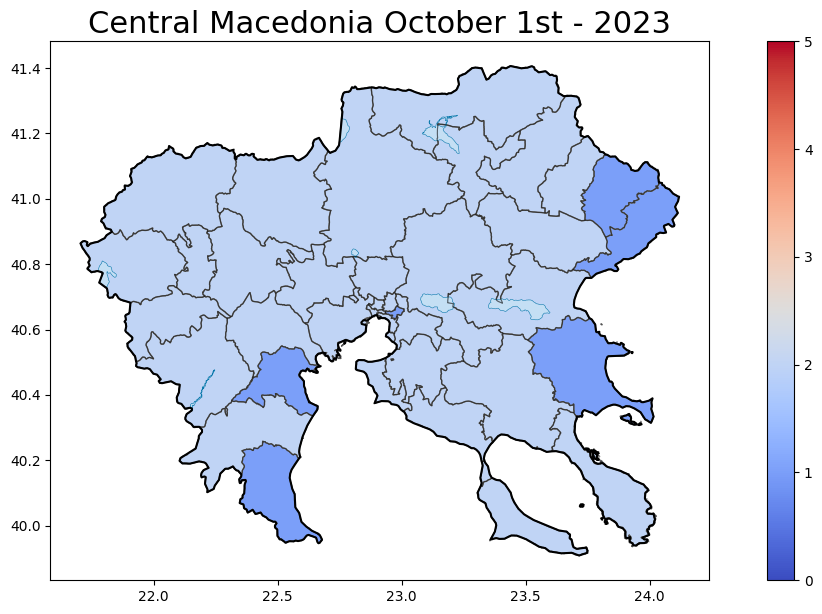

In [8]:
float_column = 'risk_class'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,7)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}
period = '1st' if PERIOD == '1st' else '15th'

fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
result_file.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 5)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2_LONG} {MONTH} {period} - 2023', size = title_size)
plt.show()